# **TITANIC PROJECT**

**Import Dependencys**

In [ ]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing  import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

**Data Load**

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
print(train.head())
test.head()

   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**DATA SUMMARIZATION**

In [ ]:
print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [ ]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

In [ ]:
train.describe()
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


**VISUALIZATION OF DATA**

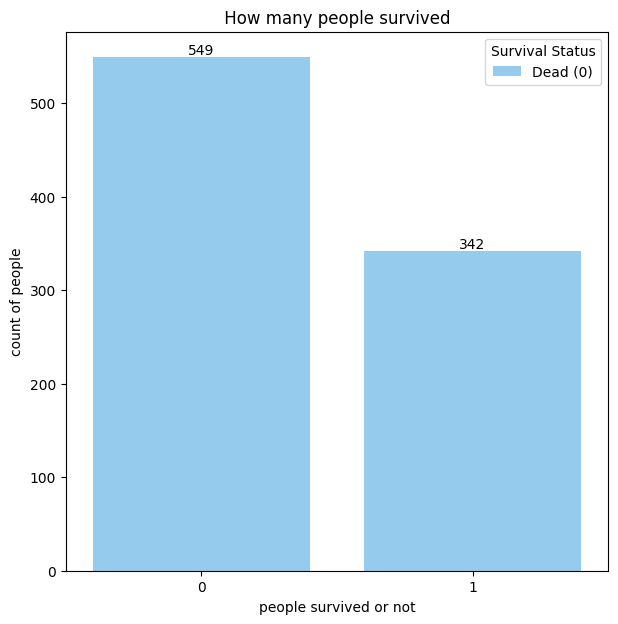

In [ ]:
fig = plt.figure(figsize=(7,7))
b = sns.countplot(data=train , x = "Survived",color = "#87CEFA")
b.bar_label(b.containers[0])
plt.legend(title="Survival Status", labels=["Dead (0)", "Survived (1)"])
plt.xlabel("people survived or not")
plt.ylabel("count of people")
plt.title(" How many people survived ")
plt.show()

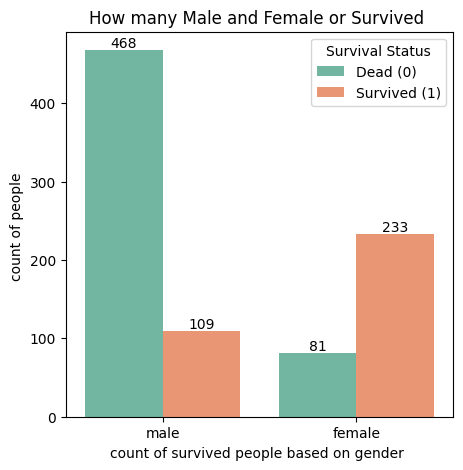

In [ ]:
fig = plt.figure(figsize=(5,5))
s = sns.countplot(data = train , x ="Sex" , hue = "Survived" , palette="Set2" )
for container in s.containers:
    s.bar_label(container)
plt.legend(title="Survival Status", labels=["Dead (0)", "Survived (1)"])
plt.xlabel("count of survived people based on gender ")
plt.ylabel("count of people ")
plt.title("How many Male and Female or Survived ")
plt.show()


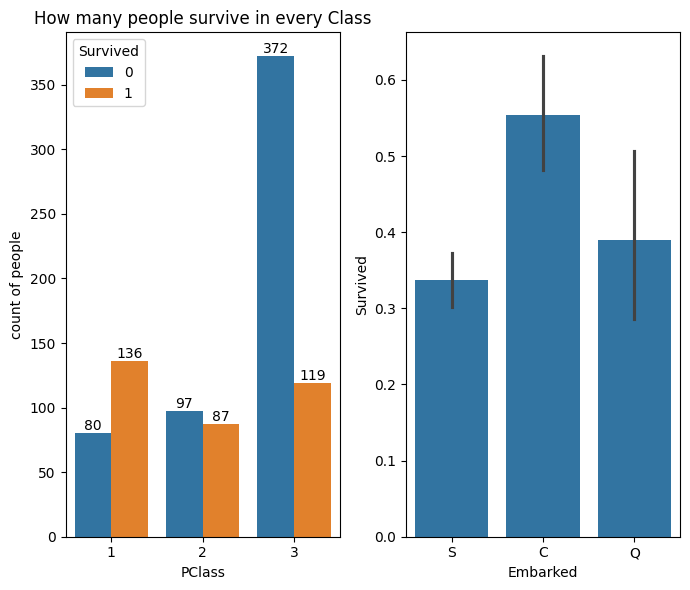

In [ ]:
plt.figure(figsize=(7, 6))
plt.subplot(1,2,1)
p = sns.countplot(data = train , x = "Pclass" , hue = "Survived")
for count in p.containers:
  p.bar_label(count)
plt.xlabel("PClass")
plt.ylabel("count of people")
plt.title("How many people survive in every Class")

plt.subplot(1,2,2)
sns.barplot(data = train , x = "Embarked" , y = "Survived")
plt.tight_layout()
plt.show()

**Outlier Detection**

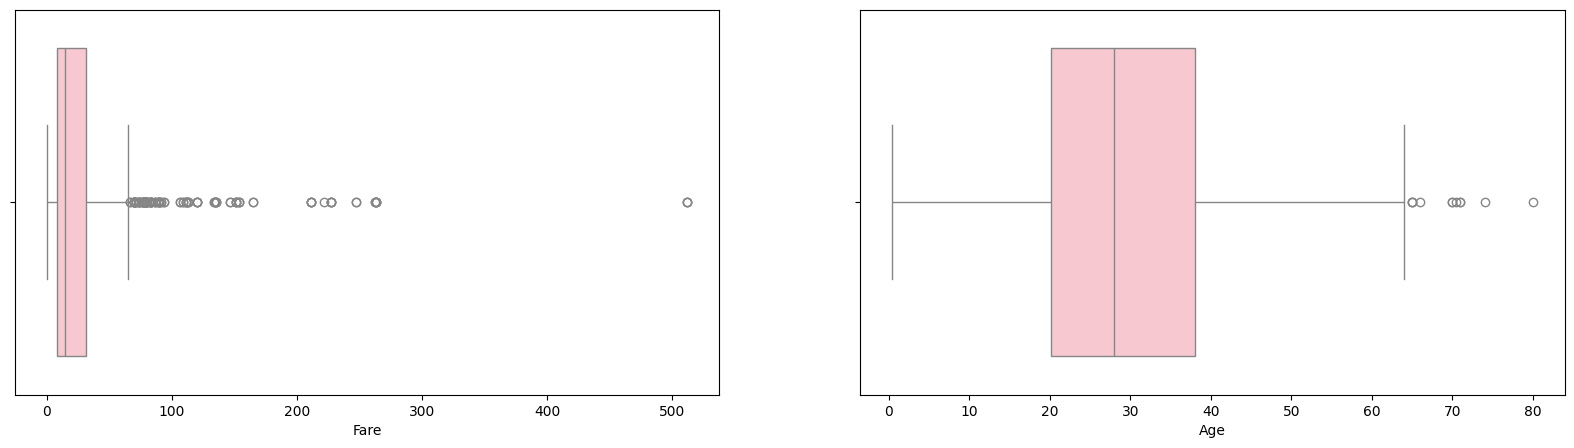

In [ ]:
plt.figure(figsize = (20,5))

plt.subplot(1,2,1)
sns.boxplot(data = train , x = "Fare",color = "Pink")

plt.subplot(1,2,2)
sns.boxplot(data = train , x = "Age" , color = "pink")
plt.show()

**Combine Train And Test Data**

In [ ]:
train["Check"] = 0
test["Check"] = 1
test["Survived"] = -1

In [ ]:
comb_df = pd.concat([train,test] , ignore_index = False)
comb_df.shape

(1309, 13)

In [ ]:
comb_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1


Null Valuese   
Age = 263    
Fare = 1   
Cabin = 1014  
Embarked  = 2  

In [ ]:
comb_df['Age'] = comb_df["Age"].fillna(train["Age"].median())
comb_df['Fare'] = comb_df["Fare"].fillna(train["Fare"].median())
comb_df["Embarked"] = comb_df["Embarked"].fillna(train["Embarked"].mode()[0])

**Handle Outlier**

In [ ]:
'''Data Leakage se bachne ke liye only train data ki limits use ki hai '''
#IQR use to handle outliers
q1 = train["Fare"].quantile(0.25)
q3 = train["Fare"].quantile(0.75)
IQR = q3 - q1
upper_bound = q3 + 1.5 * IQR
# np.where use to prevent data loss in testing data npwhere  upper limit se greater ko upper limit kar dega
comb_df["Fare"] = np.where(comb_df["Fare"] > upper_bound ,upper_bound , comb_df["Fare"] )

**Verify oulier handle or not using boxplot**

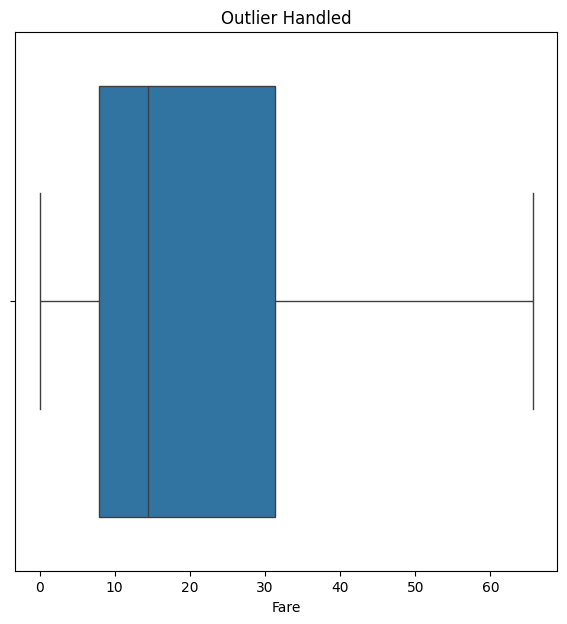

In [ ]:
plt.figure(figsize = (7,7))
sns.boxplot(data  = comb_df , x = "Fare")
plt.title("Outlier Handled")
plt.show()

**Drop Unnecessary Columns**

In [ ]:
new_comb_df = comb_df.drop(columns = ['PassengerId' , 'Name' , 'Ticket' , 'Cabin'])

**Feature Encoding**

In [ ]:
new_comb_df["Sex"] = pd.get_dummies(new_comb_df['Sex'] , drop_first = True ).astype(int)
label = LabelEncoder()
new_comb_df['Embarked'] = label.fit_transform(new_comb_df['Embarked'])

**Feature Scaling**

In [ ]:
scaler = StandardScaler()
new_comb_df[['Age','Fare']] = scaler.fit_transform(new_comb_df[['Age','Fare']])

**Split Data In Training And Testing**

In [ ]:
final_train = new_comb_df[new_comb_df['Check']==0].drop(columns = ["Check"])
final_test = new_comb_df[new_comb_df["Check"]==1]

**Model training**

In [ ]:
x = final_train.drop(columns = ["Survived"])
y = final_train["Survived"]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 10)

model = LogisticRegression(max_iter = 1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

**Chech Accuracy of model**

In [ ]:
y_pred = model.predict(x_test)
Accuracy = accuracy_score(y_test,y_pred)
print(f"Accurecy is {Accuracy * 100:.2f} achived by Logistic Regression Model",)

Accurecy is 82.12 achived by Logistic Regression Model


**Final Kaggle Submission**

In [ ]:
last_test = final_test.drop(columns = ["Survived" , "Check"])
kaggle_predictions = model.predict(last_test)

In [ ]:
submission = pd.DataFrame({
    "PassengerId" : test['PassengerId'],
    "Survived" : kaggle_predictions
})

submission['Survived'] = submission["Survived"].astype(int)


**Final File Generation**

In [ ]:
submission.to_csv("submission.csv", index = False)
print("Submission.csv file succesfull generate ")

Submission.csv file succesfull generate 


In [ ]:
sum = pd.read_csv("submission.csv")
sum.shape

(418, 2)